# Dataset Statistics & Label Distribution

Key performance indicators and label (score) distributions per dataset and combined
after z-score normalization.

In [1]:
data_path = "data/features.csv"

In [2]:
# Parameters
data_path = "data/features.csv"


In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv(data_path)
print(f"Total samples: {len(df)}")
print(f"Datasets: {df['dataset'].unique().tolist()}")

Total samples: 17870
Datasets: ['mebeauty', 'scut', 'livebeauty']


## 1. Per-Dataset KPIs

In [4]:
kpis = []
for ds in df["dataset"].unique():
    sub = df[df["dataset"] == ds]
    kpis.append({
        "dataset": ds,
        "n_samples": len(sub),
        "n_female": (sub["gender"] == "female").sum(),
        "n_male": (sub["gender"] == "male").sum(),
        "n_unknown_gender": (sub["gender"] == "unknown").sum(),
        "n_ethnicities": sub["ethnicity"].nunique(),
        "score_raw_mean": sub["score_raw"].mean(),
        "score_raw_std": sub["score_raw"].std(),
        "score_raw_min": sub["score_raw"].min(),
        "score_raw_max": sub["score_raw"].max(),
        "score_raw_median": sub["score_raw"].median(),
        "missing_pct": sub.isnull().any(axis=1).mean() * 100,
    })

kpi_df = pd.DataFrame(kpis)
print(kpi_df.to_string(index=False))

   dataset  n_samples  n_female  n_male  n_unknown_gender  n_ethnicities  score_raw_mean  score_raw_std  score_raw_min  score_raw_max  score_raw_median  missing_pct
  mebeauty       2370      1337    1033                 0              6        6.150574       1.331975       1.000000          9.625          6.285215          0.0
      scut       5500      2750    2750                 0              2        2.990891       0.688112       1.016667          4.750          2.833333          0.0
livebeauty      10000         0       0             10000              1        3.482652       0.573329       1.000000          5.000          3.500000          0.0


In [5]:
# Gender and ethnicity breakdowns
for ds in df["dataset"].unique():
    sub = df[df["dataset"] == ds]
    print(f"\n{'='*50}")
    print(f"{ds.upper()} (n={len(sub)})")
    print(f"{'='*50}")
    print(f"\nGender:\n{sub['gender'].value_counts().to_string()}")
    print(f"\nEthnicity:\n{sub['ethnicity'].value_counts().to_string()}")


MEBEAUTY (n=2370)

Gender:
gender
female    1337
male      1033

Ethnicity:
ethnicity
caucasian     980
asian         351
hispanic      296
black         296
mideastern    291
indian        156

SCUT (n=5500)

Gender:
gender
male      2750
female    2750

Ethnicity:
ethnicity
asian        4000
caucasian    1500

LIVEBEAUTY (n=10000)

Gender:
gender
unknown    10000

Ethnicity:
ethnicity
asian    10000


## 2. Raw Score Distributions (per dataset)

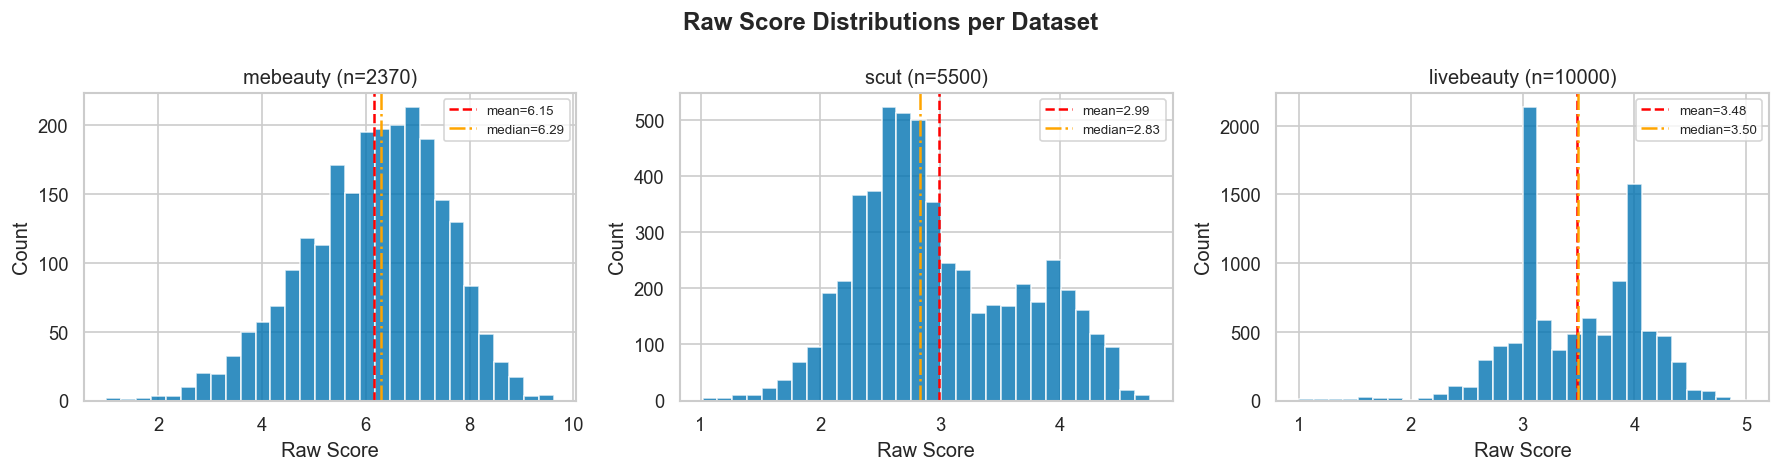

In [6]:
datasets = df["dataset"].unique()
n_ds = len(datasets)

fig, axes = plt.subplots(1, n_ds, figsize=(5 * n_ds, 4), sharey=False)
if n_ds == 1:
    axes = [axes]

for ax, ds in zip(axes, datasets):
    sub = df[df["dataset"] == ds]
    ax.hist(sub["score_raw"].dropna(), bins=30, edgecolor="white", alpha=0.8)
    ax.axvline(sub["score_raw"].mean(), color="red", linestyle="--", label=f"mean={sub['score_raw'].mean():.2f}")
    ax.axvline(sub["score_raw"].median(), color="orange", linestyle="-.", label=f"median={sub['score_raw'].median():.2f}")
    ax.set_title(f"{ds} (n={len(sub)})")
    ax.set_xlabel("Raw Score")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Raw Score Distributions per Dataset", fontweight="bold")
plt.tight_layout()
plt.show()

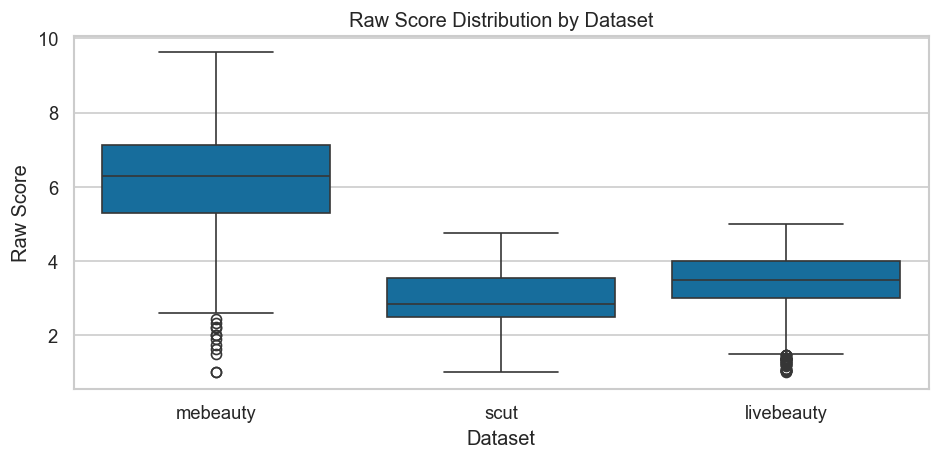

In [7]:
# Box plots by dataset
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=df, x="dataset", y="score_raw", ax=ax)
ax.set_title("Raw Score Distribution by Dataset")
ax.set_xlabel("Dataset")
ax.set_ylabel("Raw Score")
plt.tight_layout()
plt.show()

## 3. Z-Score Normalized Distribution (combined)

In [8]:
# The 'score' column is already z-normalized per dataset
print("Z-normalized score ('score' column) stats:")
print(f"  Mean:   {df['score'].mean():.4f}")
print(f"  Std:    {df['score'].std():.4f}")
print(f"  Min:    {df['score'].min():.4f}")
print(f"  Max:    {df['score'].max():.4f}")
print(f"  Median: {df['score'].median():.4f}")

print("\nPer-dataset z-score stats (should be ~0 mean, ~1 std):")
for ds in datasets:
    sub = df[df["dataset"] == ds]
    print(f"  {ds:12s}: mean={sub['score'].mean():.4f}, std={sub['score'].std():.4f}")

Z-normalized score ('score' column) stats:
  Mean:   0.0000
  Std:    0.9999
  Min:    -4.3302
  Max:    2.6466
  Median: -0.0594

Per-dataset z-score stats (should be ~0 mean, ~1 std):
  mebeauty    : mean=-0.0000, std=1.0000
  scut        : mean=0.0000, std=1.0000
  livebeauty  : mean=0.0000, std=1.0000


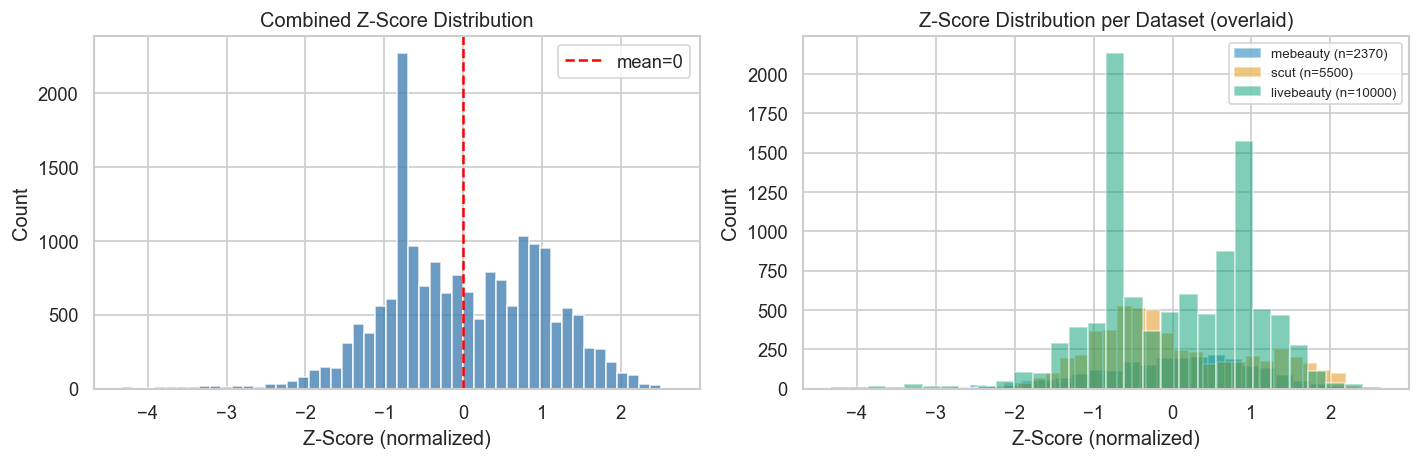

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Combined histogram
ax = axes[0]
ax.hist(df["score"].dropna(), bins=50, edgecolor="white", alpha=0.8, color="steelblue")
ax.axvline(0, color="red", linestyle="--", label="mean=0")
ax.set_title("Combined Z-Score Distribution")
ax.set_xlabel("Z-Score (normalized)")
ax.set_ylabel("Count")
ax.legend()

# Overlaid per-dataset
ax = axes[1]
for ds in datasets:
    sub = df[df["dataset"] == ds]
    ax.hist(sub["score"].dropna(), bins=30, alpha=0.5, label=f"{ds} (n={len(sub)})")
ax.set_title("Z-Score Distribution per Dataset (overlaid)")
ax.set_xlabel("Z-Score (normalized)")
ax.set_ylabel("Count")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

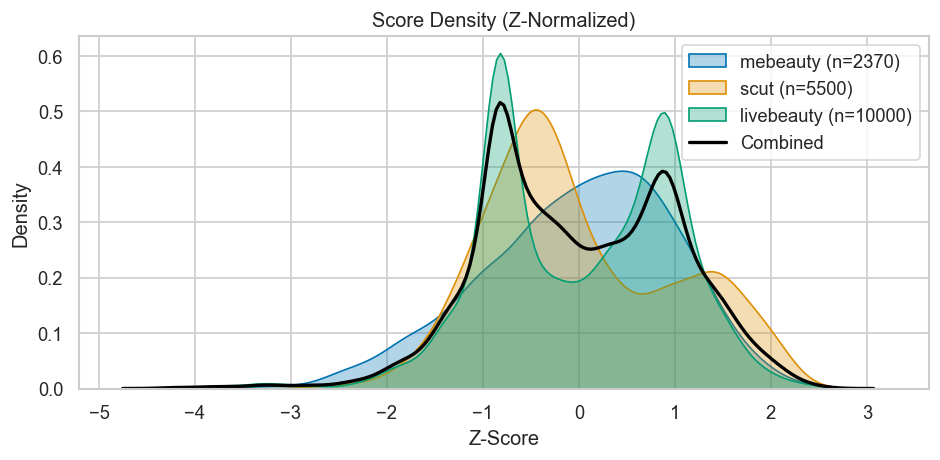

In [10]:
# KDE comparison
fig, ax = plt.subplots(figsize=(8, 4))
for ds in datasets:
    sub = df[df["dataset"] == ds]
    sns.kdeplot(sub["score"].dropna(), ax=ax, label=f"{ds} (n={len(sub)})", fill=True, alpha=0.3)

sns.kdeplot(df["score"].dropna(), ax=ax, label="Combined", color="black", linewidth=2)
ax.set_title("Score Density (Z-Normalized)")
ax.set_xlabel("Z-Score")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Label Distribution by Demographics

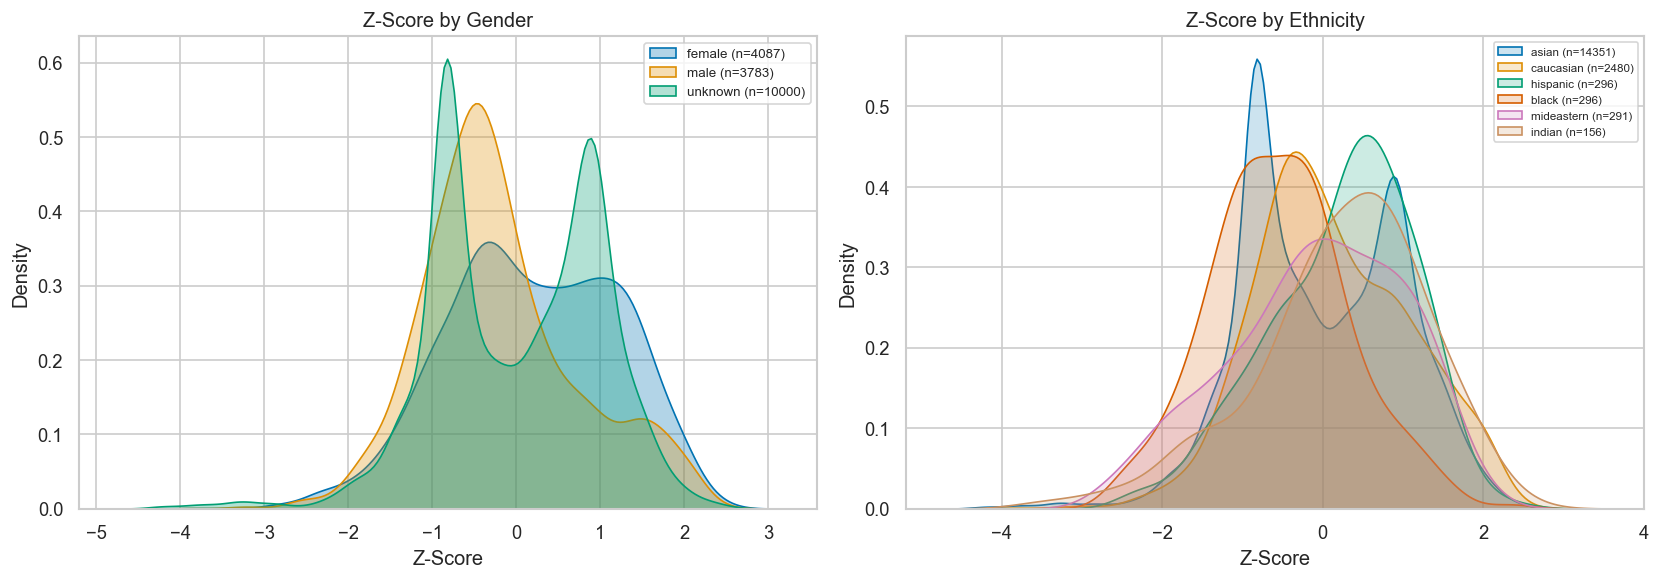

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# By gender
ax = axes[0]
for g in sorted(df["gender"].unique()):
    sub = df[df["gender"] == g]
    sns.kdeplot(sub["score"].dropna(), ax=ax, label=f"{g} (n={len(sub)})", fill=True, alpha=0.3)
ax.set_title("Z-Score by Gender")
ax.set_xlabel("Z-Score")
ax.legend(fontsize=8)

# By ethnicity
ax = axes[1]
for e in df["ethnicity"].value_counts().index:
    sub = df[df["ethnicity"] == e]
    sns.kdeplot(sub["score"].dropna(), ax=ax, label=f"{e} (n={len(sub)})", fill=True, alpha=0.2)
ax.set_title("Z-Score by Ethnicity")
ax.set_xlabel("Z-Score")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

In [12]:
# Score stats by gender and ethnicity
print("Mean z-score by gender:")
print(df.groupby("gender")["score"].agg(["mean", "std", "count"]).round(3).to_string())

print("\nMean z-score by ethnicity:")
print(df.groupby("ethnicity")["score"].agg(["mean", "std", "count"]).round(3).to_string())

Mean z-score by gender:
          mean    std  count
gender                      
female   0.191  1.017   4087
male    -0.207  0.938   3783
unknown  0.000  1.000  10000

Mean z-score by ethnicity:
             mean    std  count
ethnicity                      
asian      -0.015  1.004  14351
black      -0.548  0.855    296
caucasian   0.117  0.960   2480
hispanic    0.234  0.893    296
indian      0.217  1.070    156
mideastern -0.071  1.077    291


## 5. Combined KPI Summary

In [13]:
print("=" * 60)
print("DATASET KPI SUMMARY")
print("=" * 60)
print(f"\nTotal samples: {len(df)}")
print(f"Datasets: {n_ds}")
print(f"Features: {df.shape[1]} columns")
print(f"\nGender breakdown (all):")
for g, c in df["gender"].value_counts().items():
    print(f"  {g}: {c} ({c/len(df)*100:.1f}%)")
print(f"\nEthnicity breakdown (all):")
for e, c in df["ethnicity"].value_counts().items():
    print(f"  {e}: {c} ({c/len(df)*100:.1f}%)")
print(f"\nScore (z-normalized):")
print(f"  Range: [{df['score'].min():.2f}, {df['score'].max():.2f}]")
print(f"  IQR:   [{df['score'].quantile(0.25):.2f}, {df['score'].quantile(0.75):.2f}]")
print(f"  Skewness: {df['score'].skew():.3f}")
print(f"  Kurtosis: {df['score'].kurtosis():.3f}")
print("=" * 60)

DATASET KPI SUMMARY

Total samples: 17870
Datasets: 3
Features: 52 columns

Gender breakdown (all):
  unknown: 10000 (56.0%)
  female: 4087 (22.9%)
  male: 3783 (21.2%)

Ethnicity breakdown (all):
  asian: 14351 (80.3%)
  caucasian: 2480 (13.9%)
  hispanic: 296 (1.7%)
  black: 296 (1.7%)
  mideastern: 291 (1.6%)
  indian: 156 (0.9%)

Score (z-normalized):
  Range: [-4.33, 2.65]
  IQR:   [-0.84, 0.82]
  Skewness: -0.140
  Kurtosis: -0.140
